In [27]:
%load_ext autoreload
%autoreload 2

import os
# only load this one time per session
if 'NOTEBOOK_INITIALIZED' not in globals():
    os.chdir(os.path.dirname(os.path.abspath('.')))
    NOTEBOOK_INITIALIZED = True

import pandas as pd 
import polars as pl
import matplotlib.pyplot as plt

import src.clinvar as cv

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload



# ClinVar UTR Variant Data

The VCF file was manually downloaded from the following link: [ClinVar GRCh38 VCF](https://ftp.ncbi.nlm.nih.gov/pub/clinvar/vcf_GRCh38/clinvar.vcf.gz).

After downloading, variants located in the untranslated regions (UTRs) – including both 3' UTR and 5' UTR variants – were filtered. The filtered data was then written into a CSV file for further analysis.



In [28]:
vcf_file = cv.download_clinvar()["vcf"]

In [29]:
from genoray import VCF

vcf = VCF(vcf_file, 
          filter=lambda v: "UTR" in v.INFO.get("MC", ""))

# annotation keys to extract from the INFO field
info = [
    "AF_ESP", "AF_EXAC", "AF_TGP", "ALLELEID", "CLNDISDB", "CLNDN",
    "CLNHGVS", "CLNREVSTAT", "CLNSIG", "CLNVC", "CLNVCSO", "GENEINFO",
    "MC", "ORIGIN", "RS"
]
vcf_df = vcf.get_record_info(#contig="22",
                             attrs=["CHROM", "POS", "REF", "ALT"], 
                             info=info,
                             progress=True)
# Get the Molecular Consequence (MC) Sequence Ontology (SO) IDs and term names
vcf_df = vcf_df.with_columns(
    vcf_df["MC"].str.split("|").list.first().alias("MC_id"),
    vcf_df["MC"].str.split("|").list.last().alias("MC_term")
)

vcf_df


Reading records:   0%|          | 0/3498894 [00:00<?, ? record/s]

CHROM,POS,REF,ALT,AF_ESP,AF_EXAC,AF_TGP,ALLELEID,CLNDISDB,CLNDN,CLNHGVS,CLNREVSTAT,CLNSIG,CLNVC,CLNVCSO,GENEINFO,MC,ORIGIN,RS,MC_id,MC_term
str,i64,str,list[str],f64,f64,f64,i64,str,str,str,str,str,str,str,str,str,str,str,str,str
"""1""",981131,"""C""","[""T""]",null,null,null,3393359,"""MedGen:C3661900""","""not_provided""","""NC_000001.11:g.981131C>T""","""criteria_provided,_single_subm…","""Likely_benign""","""single_nucleotide_variant""","""SO:0001483""","""PERM1:84808""","""SO:0001623|5_prime_UTR_variant…","""1""",null,"""SO:0001623""","""intron_variant"""
"""1""",1013541,"""T""","[""C""]",0.88579,null,0.90315,1175251,"""MedGen:C3661900|MONDO:MONDO:00…","""not_provided|Mendelian_suscept…","""NC_000001.11:g.1013541T>C""","""criteria_provided,_multiple_su…","""Benign""","""single_nucleotide_variant""","""SO:0001483""","""ISG15:9636""","""SO:0001623|5_prime_UTR_variant""","""1""","""15842""","""SO:0001623""","""5_prime_UTR_variant"""
"""1""",1013549,"""GGCCCACAGCCCACA""","[""G""]",null,null,null,3213980,""".""","""ISG15-related_disorder""","""NC_000001.11:g.1013553CACAGCC[…","""no_assertion_criteria_provided""","""Likely_benign""","""Microsatellite""","""SO:0000289""","""ISG15:9636""","""SO:0001623|5_prime_UTR_variant""","""1""",null,"""SO:0001623""","""5_prime_UTR_variant"""
"""1""",1014482,"""C""","[""A""]",null,null,null,3216732,""".""","""ISG15-related_disorder""","""NC_000001.11:g.1014482C>A""","""no_assertion_criteria_provided""","""Likely_benign""","""single_nucleotide_variant""","""SO:0001483""","""ISG15:9636""","""SO:0001624|3_prime_UTR_variant""","""1""",null,"""SO:0001624""","""3_prime_UTR_variant"""
"""1""",1055000,"""C""","[""T""]",0.34176,0.33342,0.34345,249353,"""MedGen:CN169374|MONDO:MONDO:00…","""not_specified|Congenital_myast…","""NC_000001.11:g.1055000C>T""","""criteria_provided,_multiple_su…","""Benign""","""single_nucleotide_variant""","""SO:0001483""","""AGRN:375790""","""SO:0001624|3_prime_UTR_variant""","""1""","""3121561""","""SO:0001624""","""3_prime_UTR_variant"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""Y""",2787636,"""A""","[""T""]",null,null,null,3401212,"""MONDO:MONDO:0020040,MedGen:C27…","""46,XY_disorder_of_sex_developm…","""NC_000024.10:g.2787636A>T""","""no_assertion_criteria_provided""","""Benign""","""single_nucleotide_variant""","""SO:0001483""","""SRY:6736|LOC108178989:10817898…","""SO:0001623|5_prime_UTR_variant""","""1""",null,"""SO:0001623""","""5_prime_UTR_variant"""
"""NT_187633.1""",273567,"""C""","[""T""]",null,null,null,2428625,"""MedGen:CN169374""","""not_specified""",null,"""criteria_provided,_single_subm…","""Uncertain_significance""","""single_nucleotide_variant""","""SO:0001483""","""GSTT1:2952""","""SO:0001583|missense_variant,SO…","""1""",null,"""SO:0001583""","""intron_variant"""
"""NT_187633.1""",273606,"""C""","[""T""]",null,null,null,3259243,"""MedGen:CN169374""","""not_specified""",null,"""criteria_provided,_single_subm…","""Uncertain_significance""","""single_nucleotide_variant""","""SO:0001483""","""GSTT1:2952""","""SO:0001583|missense_variant,SO…","""1""",null,"""SO:0001583""","""intron_variant"""


In [31]:
cv_df = vcf_df.filter(
    (pl.col("CLNREVSTAT").str.contains("_multiple_submitters")) &
    (pl.col("CLNVC").str.contains("single_nucleotide_variant"))
)

# Convert POS column to integer before saving
cv_df = cv_df.with_columns(pl.col("POS").cast(pl.Int64))
cv_df.write_parquet("./data/UTR/clinvar_utr_snv.parquet")

print(cv_df.shape)
cv_df.head()

(37223, 21)


CHROM,POS,REF,ALT,AF_ESP,AF_EXAC,AF_TGP,ALLELEID,CLNDISDB,CLNDN,CLNHGVS,CLNREVSTAT,CLNSIG,CLNVC,CLNVCSO,GENEINFO,MC,ORIGIN,RS,MC_id,MC_term
str,i64,str,list[str],f64,f64,f64,i64,str,str,str,str,str,str,str,str,str,str,str,str,str
"""1""",1013541,"""T""","[""C""]",0.88579,null,0.90315,1175251,"""MedGen:C3661900|MONDO:MONDO:00…","""not_provided|Mendelian_suscept…","""NC_000001.11:g.1013541T>C""","""criteria_provided,_multiple_su…","""Benign""","""single_nucleotide_variant""","""SO:0001483""","""ISG15:9636""","""SO:0001623|5_prime_UTR_variant""","""1""","""15842""","""SO:0001623""","""5_prime_UTR_variant"""
"""1""",1055000,"""C""","[""T""]",0.34176,0.33342,0.34345,249353,"""MedGen:CN169374|MONDO:MONDO:00…","""not_specified|Congenital_myast…","""NC_000001.11:g.1055000C>T""","""criteria_provided,_multiple_su…","""Benign""","""single_nucleotide_variant""","""SO:0001483""","""AGRN:375790""","""SO:0001624|3_prime_UTR_variant""","""1""","""3121561""","""SO:0001624""","""3_prime_UTR_variant"""
"""1""",1055037,"""T""","[""C""]",null,null,0.38399,1282674,"""MedGen:C3661900""","""not_provided""","""NC_000001.11:g.1055037T>C""","""criteria_provided,_multiple_su…","""Benign""","""single_nucleotide_variant""","""SO:0001483""","""AGRN:375790""","""SO:0001624|3_prime_UTR_variant""","""1""","""2465136""","""SO:0001624""","""3_prime_UTR_variant"""
"""1""",1055137,"""C""","[""T""]",null,null,0.91793,1175253,"""MONDO:MONDO:0014052,MedGen:C38…","""Congenital_myasthenic_syndrome…","""NC_000001.11:g.1055137C>T""","""criteria_provided,_multiple_su…","""Benign""","""single_nucleotide_variant""","""SO:0001483""","""AGRN:375790""","""SO:0001624|3_prime_UTR_variant""","""1""","""2710872""","""SO:0001624""","""3_prime_UTR_variant"""
"""1""",1055153,"""G""","[""A""]",null,null,0.12181,1282812,"""MedGen:C3661900""","""not_provided""","""NC_000001.11:g.1055153G>A""","""criteria_provided,_multiple_su…","""Benign""","""single_nucleotide_variant""","""SO:0001483""","""AGRN:375790""","""SO:0001624|3_prime_UTR_variant""","""1""","""4308920""","""SO:0001624""","""3_prime_UTR_variant"""


### Key Definitions:

- **AF_ESP**: Allele Frequency in the ESP (Exome Sequencing Project) population.
- **AF_EXAC**: Allele Frequency in the EXAC (Exome Aggregation Consortium) population.
- **AF_TGP**: Allele Frequency in the TGP (The 1000 Genomes Project) population.
- **ALLELEID**: Unique identifier for the allele.
- **CLNDISDB**: The disease database(s) that the variant is associated with.
- **CLNDN**: Clinical diagnosis associated with the variant (e.g., disease name).
- **CLNHGVS**: The HGVS (Human Genome Variation Society) nomenclature of the variant, representing the change in nucleotide sequence.
- **CLNREVSTAT**: Review status of the clinical interpretation of the variant (e.g., how the variant's pathogenicity has been reviewed).
- **CLNSIG**: Clinical significance of the variant (e.g., benign, pathogenic, likely pathogenic).
- **CLNVC**: Variant classification (e.g., single nucleotide variant).
- **CLNVCSO**: Sequence ontology for the variant (a standardized description of the type of variation).
- **GENEINFO**: Gene associated with the variant (Gene Symbol and Gene ID).
- **MC**: Mutation classification, often indicating the molecular mechanism or impact of the variant.
- **ORIGIN**: The origin of the variant (e.g., germline or somatic).
- **RS**: dbSNP (database of single nucleotide polymorphisms) reference ID.


# Summary of Clinical Significance

Clinical Significance Counts:
shape: (12, 2)
┌─────────────────────────────────┬───────┐
│ CLNSIG                          ┆ len   │
│ ---                             ┆ ---   │
│ str                             ┆ u32   │
╞═════════════════════════════════╪═══════╡
│ Uncertain_significance          ┆ 14757 │
│ Benign                          ┆ 10325 │
│ Likely_benign                   ┆ 6122  │
│ Benign/Likely_benign            ┆ 3807  │
│ Pathogenic/Likely_pathogenic    ┆ 1097  │
│ …                               ┆ …     │
│ Uncertain_significance/Uncerta… ┆ 12    │
│ Pathogenic/Likely_pathogenic/P… ┆ 2     │
│ Benign|confers_sensitivity      ┆ 1     │
│ Benign|other                    ┆ 1     │
│ Benign/Likely_benign|other      ┆ 1     │
└─────────────────────────────────┴───────┘


<Figure size 1000x800 with 0 Axes>

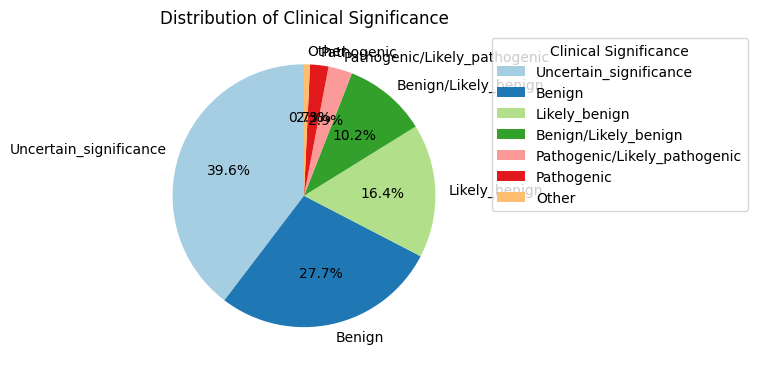

In [ ]:
# count the occurrences of each clinical significance value
clnsig_counts = cv_df.group_by("CLNSIG").len().sort("len", descending=True)

print("Clinical Significance Counts:")
print(clnsig_counts)

# select the top N categories and combine the rest into 'Other'
top_n = 6
top_categories = clnsig_counts.head(top_n)
other_categories = clnsig_counts.tail(len(clnsig_counts) - top_n).select(pl.col("len").cast(pl.UInt32).sum()).item()
other_row = pl.DataFrame({"CLNSIG": ["Other"], "len": [other_categories]})
clnsig_counts_filtered = pl.concat([top_categories.with_columns(pl.col("len").cast(pl.Int64)),
                                     other_row])

# Convert to pandas for plotting
clnsig_counts_pd = clnsig_counts_filtered.to_pandas().set_index("CLNSIG")

plt.figure(figsize=(10, 8))
ax = clnsig_counts_pd.plot(kind='pie', y="len", autopct='%1.1f%%', startangle=90, legend=False, colors=plt.cm.Paired.colors)
plt.title('Distribution of Clinical Significance')
plt.ylabel('')
plt.legend(clnsig_counts_pd.index, title="Clinical Significance", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


# Data summary

# Effect of Variants

<Figure size 1200x800 with 0 Axes>

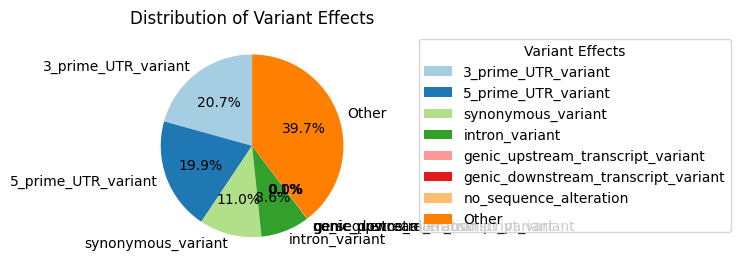

In [58]:
# count the occurrences of each variant effect
effect_counts = cv_df.group_by("MC_term").len().sort("len", descending=True)

# select the top N categories and combine the rest into 'Other'
top_n = 8
top_effects = effect_counts.head(top_n)
other_effects = effect_counts.tail(len(effect_counts) - top_n).select(pl.col("len").cast(pl.UInt32).sum()).item()
other_row = pl.DataFrame({"MC_term": ["Other"], "len": [other_effects]})
effect_counts_filtered = pl.concat([top_effects.with_columns(pl.col("len").cast(pl.Int64)),
                                     other_row])

# Convert to pandas for plotting
effect_counts_pd = effect_counts_filtered.to_pandas().set_index("MC_term")

plt.figure(figsize=(12, 8))
ax = effect_counts_pd.plot(kind='pie', y="len", autopct='%1.1f%%', startangle=90, legend=False, colors=plt.cm.Paired.colors)
plt.title('Distribution of Variant Effects')
plt.ylabel('')
plt.legend(effect_counts_pd.index, title="Variant Effects", bbox_to_anchor=(1.2, 1), loc='upper left')
plt.tight_layout()
plt.show()


# Distribution of Allele Frequencies

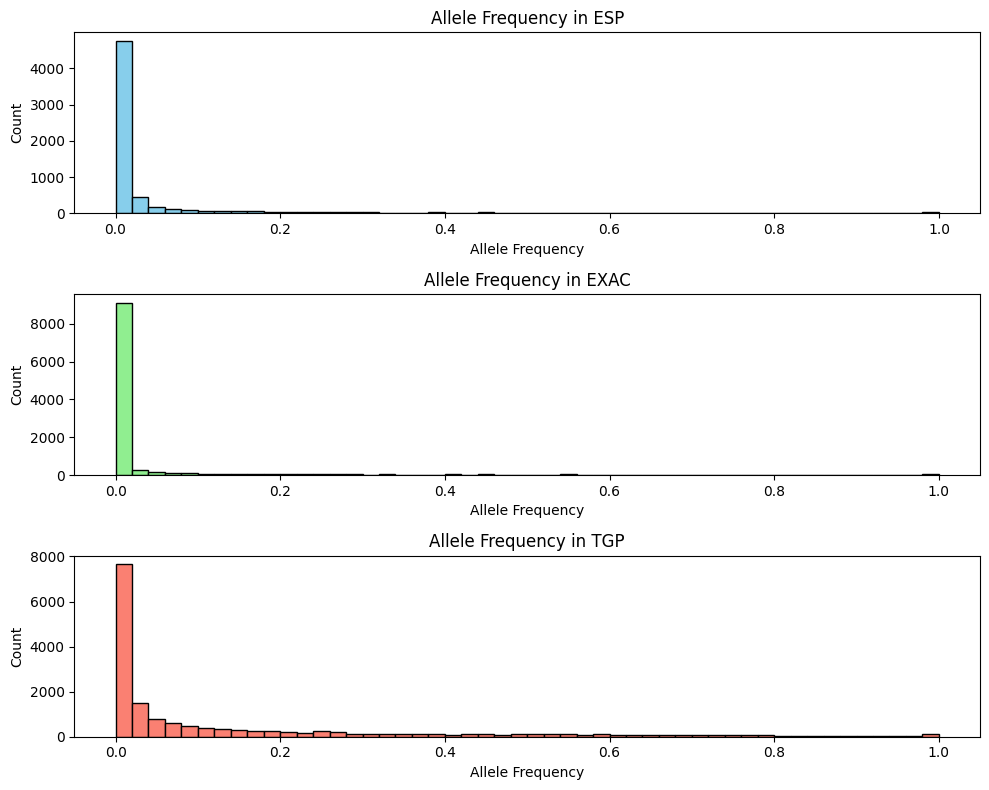

In [64]:
# histograms of allele frequencies
plt.figure(figsize=(10, 8))

bins = 50
datasets = [
    ('AF_ESP', 'skyblue', 'Allele Frequency in ESP'),
    ('AF_EXAC', 'lightgreen', 'Allele Frequency in EXAC'),
    ('AF_TGP', 'salmon', 'Allele Frequency in TGP')
]

for i, (col, color, title) in enumerate(datasets, 1):
    plt.subplot(3, 1, i)
    plt.hist(cv_df.filter(pl.col(col).is_not_null())[col].to_numpy(), 
             bins=bins, color=color, edgecolor='black')
    plt.title(title)
    plt.xlabel('Allele Frequency')
    plt.ylabel('Count')

plt.tight_layout()
plt.show()


# Clinical Significance by Variant Effect

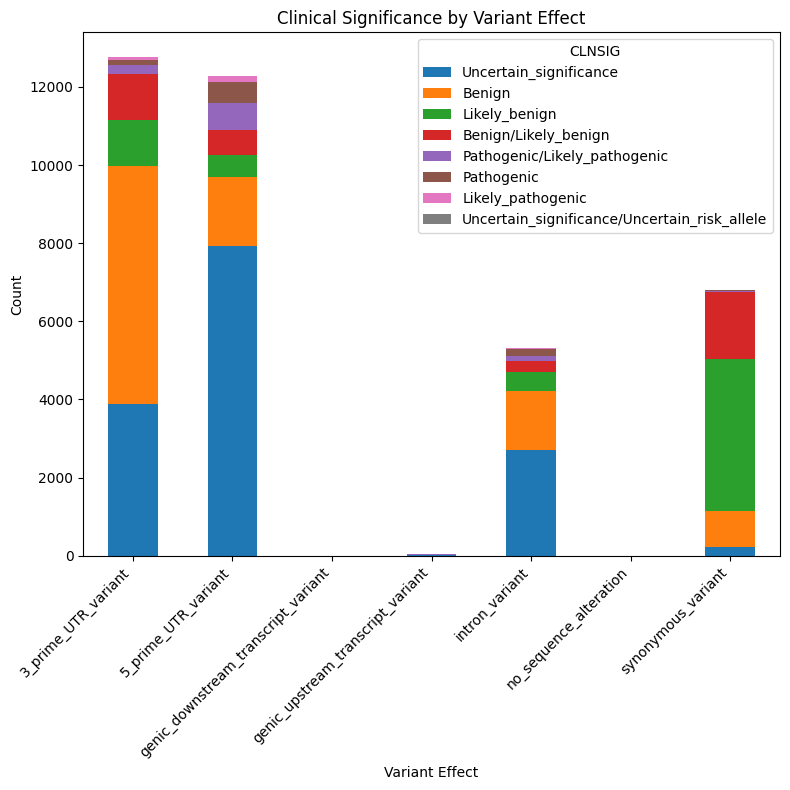

In [77]:
# group by Effect and CLNSIG, and count the occurrences
effect_clnsig_counts = cv_df.to_pandas().groupby(['MC_term', 'CLNSIG']).size().unstack().fillna(0)

top_8_clnsig = effect_clnsig_counts.sum(axis=0).nlargest(8).index

effect_clnsig_counts_top_8 = effect_clnsig_counts[top_8_clnsig]

# plot the stacked bar chart
effect_clnsig_counts_top_8.plot(kind='bar', stacked=True, figsize=(8, 8))
plt.title('Clinical Significance by Variant Effect')
plt.xlabel('Variant Effect')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


# Gene Distribution

Top 10 Genes with the Most Variants:
GENEINFO
CDH1:999       1023
PMS2:5395       753
MSH6:2956       679
MLH1:4292       658
APC:324         571
CHEK2:11200     529
BLM:641         382
PRX:57716       324
CTNNA1:1495     317
PTEN:5728       294
Name: count, dtype: int64


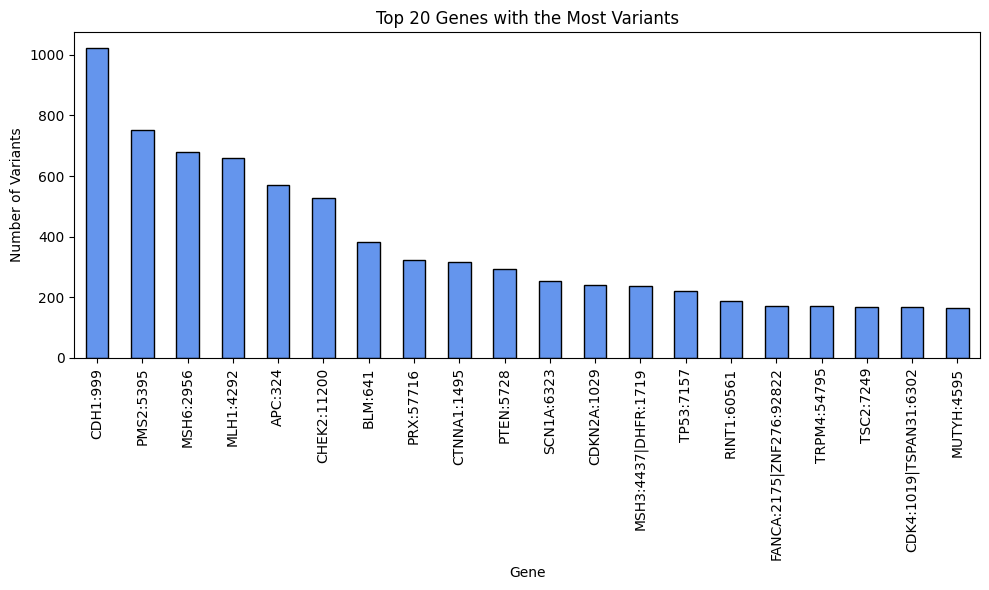

In [79]:
# count the number of variants associated with each gene
gene_counts = cv_df['GENEINFO'].to_pandas().value_counts()


print("Top 10 Genes with the Most Variants:")
print(gene_counts.head(10))

# plot the distribution of variants per gene 
plt.figure(figsize=(10, 6))
gene_counts.head(20).plot(kind='bar', color='cornflowerblue', edgecolor='black')
plt.title('Top 20 Genes with the Most Variants')
plt.xlabel('Gene')
plt.ylabel('Number of Variants')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()
